# DATASCI 503, Group Work 10: Stochastic Gradient Descent for Loss Functions

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. **During lab, feel free to flag down your GSI to ask questions at any point!**

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Part 1: Gradient Descent for a Given Function

---

**Problem 1:** Gradient Descent for a Function of One Argument

Recall that gradient descent is an optimization algorithm used to minimize some function by iteratively moving in the direction of steepest descent as defined by the negative of the function's gradient.

Namely, the procedure is as follows:
1. Start with a random point $w$.
2. Update $w$ by moving in the direction of the negative gradient of the function at $w$: $$w \leftarrow w - \eta \nabla f(w).$$
Here, $\eta$ is the *learning rate*; it controls the size of the step we're taking in the direction of the negative gradient.
3. Repeat step 2 until the variable $w$ changes very little between iterations.

Below, write code to minimize $$f(w) = (w -2)^2$$ using gradient descent. Your function should return the minimizer $w^*$.

In [3]:
def gradient_descent_1d(epsilon: float, initial_w: float, eta: float) -> float:
    """
    Minimize f(w) = (w - 2)^2 using gradient descent.

    Args:
        epsilon: tolerance for convergence
        initial_w: initial value of w
        eta: learning rate

    Returns:
        The minimizer w* (approximately 2.0)
    """
    w = initial_w
    while True:
        grad = 2 * (w - 2)  # Gradient of f(w) = (w - 2)^2
        w_new = w - eta * grad  # Update rule
        if abs(w_new - w) < epsilon:  # Check for convergence
            break
        w = w_new
    return w

In [4]:
# Test assertions
result = gradient_descent_1d(epsilon=0.0001, initial_w=5.0, eta=0.1)
assert abs(result - 2) < 0.001, f"Expected result near 2, got {result}"

result_neg = gradient_descent_1d(epsilon=0.0001, initial_w=-3.0, eta=0.1)
assert abs(result_neg - 2) < 0.001, f"Expected result near 2 from negative start, got {result_neg}"

print("All tests passed!")



All tests passed!


---

**Problem 2:** Gradient Descent for a Function of Two Arguments

Now we want to minimize the Rosenbrock function:

$$f(w_1, w_2) = (1-w_1)^2 + 100 (w_2 - w_1^2)^2$$

using gradient descent. The minimum is at $(1, 1)$.

**Hint:** You can treat $w$ as a vector, but this is not necessary.

**Hint:** If your algorithm is not converging, try adjusting the learning rate first. The Rosenbrock function has a narrow curved valley, so a smaller learning rate may be needed.

In [5]:
def gradient_descent_2d(epsilon: float, initial_w: np.ndarray, eta: float) -> np.ndarray:
    """
    Minimize the Rosenbrock function using gradient descent.

    Args:
        epsilon: tolerance for convergence
        initial_w: initial weight vector [w1, w2]
        eta: learning rate

    Returns:
        The minimizer (approximately [1.0, 1.0])
    """
    w = initial_w.astype(float).copy() # Ensure we have a float copy of the initial weights

    while True:
        w1, w2 = w

        grad_w1 = 2 * (w1 - 1) - 400 * w1 * (w2 - w1**2)
        grad_w2 = 200 * (w2 - w1**2)
        grad = np.array([grad_w1, grad_w2])

        w_new = w - eta * grad

        if np.linalg.norm(w_new - w, ord=2) < epsilon:
            break

        w = w_new

    return w

In [6]:
# Test assertions
result = gradient_descent_2d(epsilon=0.00001, initial_w=np.array([2.0, 1.0]), eta=0.001)
expected = np.array([1.0, 1.0])
assert np.linalg.norm(result - expected, 2) < 0.05, f"Expected near [1, 1], got {result}"

result2 = gradient_descent_2d(epsilon=0.00001, initial_w=np.array([0.0, 0.0]), eta=0.001)
assert (
    np.linalg.norm(result2 - expected, 2) < 0.05
), f"Expected near [1, 1] from origin, got {result2}"

print("All tests passed!")



All tests passed!


## Part 2: Gradient Descent for Linear Regression

The previous functions just depended on some parameters $(w_1, w_2)$. Now we are interested in optimizing loss functions that depend on data $(X, y)$.

---

**Problem 3:** Simple Linear Regression

We are interested in:

1. Fitting a simple linear model:
$$\widehat{y}_i = \alpha + \beta x_i$$

2. By minimizing the mean squared error loss:
$$L(\alpha, \beta) = \frac{1}{2n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 = \frac{1}{2n}\sum_{i=1}^n (y_i - \alpha - \beta x_i)^2$$

   (Note: The $\frac{1}{2}$ factor is a convention in machine learning; it simplifies the gradient and does not change the minimizer.)

3. Using gradient descent updates:
$$\alpha_k = \alpha_{k-1} - \eta \frac{\partial L}{\partial \alpha}$$
$$\beta_k = \beta_{k-1} - \eta \frac{\partial L}{\partial \beta}$$

You can check convergence of gradient descent in either of two ways:

- Check if the parameter changes are smaller than epsilon:
$$|\alpha_k - \alpha_{k-1}| + |\beta_k - \beta_{k-1}| < \epsilon$$

- Or check whether the change in the loss function is smaller than epsilon:
$$|L_k - L_{k-1}| < \epsilon$$

**In this problem, use the former.**

In [7]:
def simple_linear_regression_gd(
    features: np.ndarray,
    targets: np.ndarray,
    eta: float,
    initial_alpha: float,
    initial_beta: float,
    epsilon: float,
) -> tuple[float, float]:
    """
    Fit simple linear regression using gradient descent.

    Args:
        features: input feature array (1D)
        targets: target values array (1D)
        eta: learning rate
        initial_alpha: initial intercept value
        initial_beta: initial slope value
        epsilon: convergence tolerance

    Returns:
        Tuple of (alpha, beta) - the fitted intercept and slope
    """
    alpha = initial_alpha
    beta = initial_beta
    n = len(features)

    while True:
        predictions = alpha + beta * features
        errors = predictions - targets # makes sign of residuals consistent

        # Compute gradients
        grad_alpha = (1 / n) * np.sum(errors)
        grad_beta = (1 / n) * np.sum(errors * features)

        alpha_new = alpha - eta * grad_alpha
        beta_new = beta - eta * grad_beta
        
        if abs(alpha_new - alpha) + abs(beta_new - beta) < epsilon:
            alpha, beta = alpha_new, beta_new
            break

        alpha, beta = alpha_new, beta_new

    return alpha, beta

Use the following cells to test your solution. The obtained coefficients do not need to be exactly the same as scikit-learn's, but should be close. Making epsilon smaller will yield more accurate results.

In [8]:
# Generate some random data for testing
np.random.seed(42)
x_test = np.random.rand(100)
true_alpha = np.random.rand(1)
true_beta = np.random.rand(1)
y_test = true_alpha + x_test * true_beta + np.random.rand(100) / 10

Check the solution using scikit-learn:

In [9]:
from sklearn.linear_model import LinearRegression

lr_simple = LinearRegression()
_ = lr_simple.fit(x_test[:, None], y_test)
print(f"Sklearn intercept: {lr_simple.intercept_}, slope: {lr_simple.coef_[0]}")

Sklearn intercept: 0.08098038792943829, slope: 0.6370278378408694


In [10]:
# Test assertions
eta, initial_alpha, initial_beta, epsilon = 0.1, 0, 0, 0.0001
alpha_hat, beta_hat = simple_linear_regression_gd(
    x_test, y_test, eta, initial_alpha, initial_beta, epsilon
)
print(f"Gradient descent intercept: {alpha_hat}, slope: {beta_hat}")

sklearn_params = np.array([lr_simple.intercept_, lr_simple.coef_[0]])
gd_params = np.array([alpha_hat, beta_hat])
assert (
    np.linalg.norm(gd_params - sklearn_params, 1) < 0.1
), f"Parameters differ too much from sklearn: {gd_params} vs {sklearn_params}"

print("All tests passed!")


Gradient descent intercept: 0.08567387278803358, slope: 0.6277520519312986
All tests passed!


---

**Problem 4:** Multivariate Linear Regression

Now implement gradient descent for multivariate linear regression with multiple features.

The loss function for multivariate linear regression is:

$$L(w) = \frac{1}{2n}\sum_{i=1}^n (y_i - x_i^T w)^2 = \frac{1}{2n}||Y - X w||^2$$

where each $x_i$ is a row vector (or correspondingly, $X$ is a matrix with rows as samples), and $y_i$ is the corresponding element of the target vector $Y$.

The gradient of this loss function is:

$$\nabla L = \frac{1}{n} X^T(Xw - Y)$$

The gradient descent update rule in vector form is:

$$w_k = w_{k-1} - \eta \nabla L$$

where $w$ is the weight vector, $\eta$ is the learning rate, and $\nabla L$ is the gradient.

Gradient descent converges when either:
- The weight change is smaller than epsilon: $||w_k - w_{k-1}|| < \epsilon$
- The loss change is smaller than epsilon: $|L_k - L_{k-1}| < \epsilon$

Unlike in the previous question, please also keep track of the loss at each iteration and return the complete loss history.


**Note:** Your function should automatically add a column of ones to X to fit the intercept term.

In [11]:
def multivariate_linear_regression_gd(
    features: np.ndarray,
    targets: np.ndarray,
    eta: float,
    initial_weights: np.ndarray,
    epsilon: float,
) -> tuple[np.ndarray, list]:
    """
    Fit multivariate linear regression using gradient descent.

    Args:
        features: input feature matrix (n_samples x n_features)
        targets: target values array (n_samples,)
        eta: learning rate
        initial_weights: initial weight vector (n_features + 1,) including intercept
        epsilon: convergence tolerance

    Returns:
        Tuple of (weights, losses) where weights is the fitted weight vector
        and losses is the list of loss values at each iteration
    """
    X = np.asarray(features)
    y = np.asarray(targets).reshape(-1, 1) # Ensure targets are column vector
    w = np.asarray(initial_weights, dtype=float).copy()

    # Add intercept term to features
    X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
    n = X_with_intercept.shape[0]
    losses = []

    while True:
        predictions = X_with_intercept @ w
        residuals = predictions - y  

        loss = 0.5 * np.mean(residuals ** 2)
        losses.append(loss)

        grad = (1 / n) * (X_with_intercept.T @ residuals)
        w_new = w - eta * grad

        if np.linalg.norm(w_new - w, ord=2) < epsilon:
            w = w_new
            break

        w = w_new

    return w, losses

We will use real-world data to test our solution. The coefficients obtained may not match sklearn exactly, but the training loss should decrease monotonically and be comparable to sklearn's solution.

In [12]:
# Load and prepare the California housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing_data = fetch_california_housing(return_X_y=True, as_frame=True)
housing_features = housing_data[0]
housing_targets = housing_data[1]
housing_train_features, housing_val_features, housing_train_targets, housing_val_targets = (
    train_test_split(housing_features, housing_targets, test_size=0.3, random_state=42)
)
housing_scaler = StandardScaler()
housing_train_scaled = housing_scaler.fit_transform(housing_train_features)

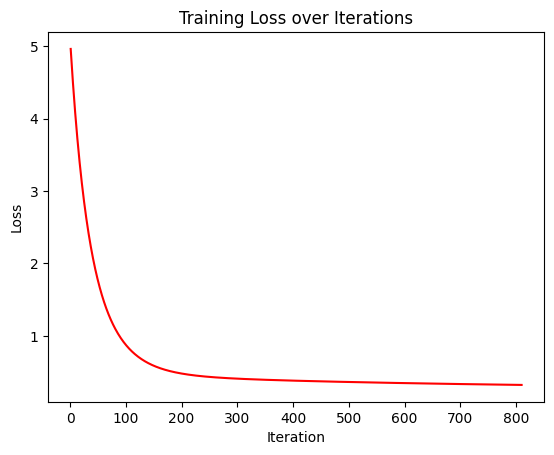

Final training loss: 0.32359024335921843
Validation loss: 0.31758882246954867
All tests passed!


In [13]:
# Test assertions
np.random.seed(42)
housing_num_weights = housing_features.shape[1] + 1
housing_weights_gd, housing_loss_history = multivariate_linear_regression_gd(
    housing_train_scaled,
    housing_train_targets,
    eta=0.01,
    initial_weights=np.random.randn(housing_num_weights, 1),
    epsilon=0.001,
)

# Compute predictions on validation set
housing_val_scaled = housing_scaler.transform(housing_val_features)
housing_val_with_intercept = np.hstack(
    (np.ones((housing_val_features.shape[0], 1)), housing_val_scaled)
)
housing_predictions_val = housing_val_with_intercept @ housing_weights_gd
housing_val_targets_reshaped = np.array(housing_val_targets).reshape(
    (housing_val_targets.shape[0], 1)
)

plt.plot(np.arange(1, len(housing_loss_history) + 1), housing_loss_history, color="red")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.show()

print(f"Final training loss: {housing_loss_history[-1]}")
val_loss = 0.5 * np.mean((housing_val_targets_reshaped - housing_predictions_val) ** 2)
print(f"Validation loss: {val_loss}")

# Verify loss decreases (allowing small numerical fluctuations)
assert len(housing_loss_history) > 1, "Should have multiple iterations"
assert housing_loss_history[-1] < housing_loss_history[0], "Loss should decrease overall"

print("All tests passed!")



In [14]:
# Compare with sklearn's LinearRegression
housing_sklearn_model = LinearRegression(fit_intercept=True)
_ = housing_sklearn_model.fit(housing_train_scaled, housing_train_targets)
print(f"Sklearn intercept: {housing_sklearn_model.intercept_}")
print(f"Sklearn coefficients: {housing_sklearn_model.coef_}")

Sklearn intercept: 2.0692396089424165
Sklearn coefficients: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


In [15]:
print(housing_weights_gd.shape, housing_sklearn_model.coef_.shape)
print(f"Gradient descent weights: {housing_weights_gd.flatten()}")
print(f"Sklearn weights: {housing_sklearn_model.coef_.flatten()}")

(9, 1) (8,)
Gradient descent weights: [ 2.06878136  0.60878131  0.20995757  0.40423093 -0.35211329  0.03141609
 -0.0425422  -0.42448477 -0.3581773 ]
Sklearn weights: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


In [16]:
# Compare losses between gradient descent and sklearn
sklearn_train_pred = housing_sklearn_model.predict(housing_train_scaled)
housing_sklearn_train_loss = 0.5 * np.mean((housing_train_targets - sklearn_train_pred) ** 2)
sklearn_val_pred = housing_sklearn_model.predict(housing_val_scaled)
housing_sklearn_val_loss = 0.5 * np.mean((housing_val_targets - sklearn_val_pred) ** 2)
print(f"Sklearn training loss: {housing_sklearn_train_loss}")
print(f"Sklearn validation loss: {housing_sklearn_val_loss}")

Sklearn training loss: 0.2616788144133877
Sklearn validation loss: 0.2652838912383376


---

**Problem 5:** Minibatch Gradient Descent

In mini-batch gradient descent, we apply gradient descent to a subset of the data (called a mini-batch or batch) at each iteration. The algorithm is as follows:

**Inputs:** $X, Y, w_0, \eta, \epsilon, |B|$ (batch size)

**Step 0:** Set $n$ = number of samples and calculate the number of batches as $m = \lceil n/|B| \rceil$

**Step 1:** Initialize weights $w_k = w_0$

**Step 2:** Repeat until $||w_k - w_{k-1}|| < \epsilon$:

- **Step 2a:** Randomly shuffle the data and split into $m$ batches: $B_1, B_2, \ldots, B_m$

- **Step 2b:** For each batch $j \in \{1, 2, \ldots, m\}$, apply the gradient descent update using only that batch's data:
$$w_k = w_{k-1} - \eta \frac{1}{|B_j|} X_{B_j}^T(X_{B_j} w_{k-1} - Y_{B_j})$$

- **Step 2c:** After processing all batches, compute and store the loss on the **full** dataset:
$$L_k = \frac{1}{2n}||Y - X w_k||^2$$

**Output:** $w_k$, $[L_1, L_2, \ldots, L_k]$

Write a function for mini-batch gradient descent that returns $\widehat{w}$ and the loss history. This function should work with any batch size.

**Hint:** You can use `np.random.permutation(n)` to get a random permutation of indices, then use these to shuffle both X and y together:

```python
# Shuffle X and y together using the same permutation
shuffle_indices = np.random.permutation(num_samples)
X_shuffled = X[shuffle_indices]
y_shuffled = y[shuffle_indices]

# Get the j-th minibatch
X_batch = X_shuffled[j * batch_size : (j + 1) * batch_size]
y_batch = y_shuffled[j * batch_size : (j + 1) * batch_size]
```

Note that $X$ and $y$ must **always be shuffled together** (think about why this is necessary!).

Use a for loop with index $j$ going from 0 to $\lceil n / |B| \rceil - 1$ and apply a gradient descent step on the data from the $j$-th batch. If $|B|$ does not divide $n$ evenly, the last batch will be smaller.

In [17]:
def minibatch_gradient_descent(
    features: np.ndarray,
    targets: np.ndarray,
    eta: float,
    initial_weights: np.ndarray,
    epsilon: float,
    batch_size: int,
) -> tuple[np.ndarray, list]:
    """
    Fit multivariate linear regression using mini-batch gradient descent.
    """
    X = np.asarray(features)
    y = np.asarray(targets).reshape(-1, 1)
    w = np.asarray(initial_weights, dtype=float).copy()

    X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
    n = X_with_intercept.shape[0]
    num_batches = int(np.ceil(n / batch_size)) # Calculate number of batches
    losses = []

    while True:
        w_prev = w.copy() # Store previous weights for convergence check

        # Shuffle the data; X and y must be shuffled in the same way to maintain correspondence
        shuffle_indices = np.random.permutation(n)
        X_shuffled = X_with_intercept[shuffle_indices]
        y_shuffled = y[shuffle_indices]

        for j in range(num_batches):
            start = j * batch_size
            end = min((j + 1) * batch_size, n)

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            residuals = X_batch @ w - y_batch
            grad = (1 / len(X_batch)) * (X_batch.T @ residuals)
            w = w - eta * grad

        full_residuals = X_with_intercept @ w - y
        losses.append(0.5 * np.mean(full_residuals ** 2))

        if np.linalg.norm(w - w_prev, ord=2) < epsilon:
            break

    return w, losses

We can reuse the test setup from the previous question, as we are again solving multivariate linear regression, this time with mini-batch optimization. The same caveats apply.

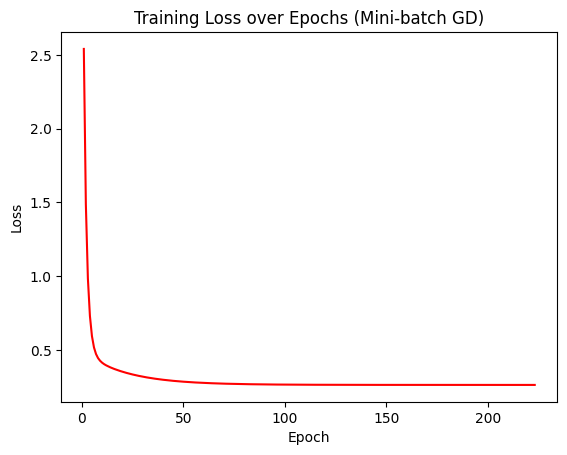

Final training loss: 0.2616922821613909
Validation loss: 0.26492094100469676
All tests passed!


In [18]:
# Test assertions
np.random.seed(42)
housing_weights_minibatch, housing_loss_history_minibatch = minibatch_gradient_descent(
    housing_train_scaled,
    housing_train_targets,
    eta=0.01,
    initial_weights=np.random.randn(housing_num_weights, 1),
    epsilon=0.001,
    batch_size=512,
)

# Compute predictions on validation set
housing_predictions_minibatch = housing_val_with_intercept @ housing_weights_minibatch

plt.plot(
    np.arange(1, len(housing_loss_history_minibatch) + 1),
    housing_loss_history_minibatch,
    color="red",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs (Mini-batch GD)")
plt.show()

print(f"Final training loss: {housing_loss_history_minibatch[-1]}")
minibatch_val_loss = 0.5 * np.mean(
    (housing_val_targets_reshaped - housing_predictions_minibatch) ** 2
)
print(f"Validation loss: {minibatch_val_loss}")

# Verify loss decreases overall
assert len(housing_loss_history_minibatch) > 1, "Should have multiple epochs"
assert (
    housing_loss_history_minibatch[-1] < housing_loss_history_minibatch[0]
), "Loss should decrease overall"

print("All tests passed!")


In [19]:
# Compare with sklearn's LinearRegression (same as before)
print(f"Sklearn intercept: {housing_sklearn_model.intercept_}")
print(f"Sklearn coefficients: {housing_sklearn_model.coef_}")

Sklearn intercept: 2.0692396089424165
Sklearn coefficients: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


In [20]:
print(housing_weights_minibatch.shape, housing_sklearn_model.coef_.shape)
print(f"Mini-batch GD weights: {housing_weights_minibatch.flatten()}")
print(f"Sklearn weights: {housing_sklearn_model.coef_.flatten()}")

(9, 1) (8,)
Mini-batch GD weights: [ 2.06951957e+00  8.45293105e-01  1.22313398e-01 -2.86914445e-01
  3.36387297e-01 -7.91862323e-04 -4.09229692e-02 -8.94596025e-01
 -8.66978292e-01]
Sklearn weights: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


In [21]:
# Compare losses
print(f"Sklearn training loss: {housing_sklearn_train_loss}")
print(f"Sklearn validation loss: {housing_sklearn_val_loss}")

Sklearn training loss: 0.2616788144133877
Sklearn validation loss: 0.2652838912383376
